In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load data
data_path = '/content/drive/MyDrive/tweet_party_mention_2026-02-15.csv'
df = pd.read_csv(data_path)
print(df.head())
df.shape

                                          tweet_text     Party  is_mentioned
0  திருப்பூர் மாவட்டம் இடுவாய் கிராமத்தில் , பொது...      ADMK             0
1  திருப்பூர் மாவட்டம் இடுவாய் கிராமத்தில் , பொது...       BJP             1
2  திருப்பூர் மாவட்டம் இடுவாய் கிராமத்தில் , பொது...  Congress             0
3  திருப்பூர் மாவட்டம் இடுவாய் கிராமத்தில் , பொது...       DMK             1
4  திருப்பூர் மாவட்டம் இடுவாய் கிராமத்தில் , பொது...       NTK             0


(1200, 3)

In [ ]:
# Load IndicBERT tokenizer and model
model_name = "ai4bharat/indic-bert"
tokenizer = AutoTokenizer.from_pretrained("ai4bharat/IndicBERTv2-MLM-only")
base_model = AutoModel.from_pretrained("ai4bharat/IndicBERTv2-MLM-only")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.75M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:

from sklearn.model_selection import train_test_split

# Split data into train and test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['is_mentioned'])

# Prepare dataset
class TweetPartyDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        tweet = str(row['tweet_text'])
        party = str(row['Party'])
        label = row['is_mentioned']

        encoding = self.tokenizer(
            tweet,
            party,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.float)
        }


# Create datasets and dataloaders
train_dataset = TweetPartyDataset(train_df, tokenizer)
test_dataset = TweetPartyDataset(test_df, tokenizer)
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [ ]:
# Define the TC-PED model
class TCPEDModel(nn.Module):
    def __init__(self, base_model, hidden_dim=768, hidden_units=128, dropout=0.2):
        super(TCPEDModel, self).__init__()
        self.base_model = base_model
        self.cls_linear = nn.Linear(hidden_dim, hidden_units)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_units, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state  # (batch, seq_len, hidden_dim)

        # Use CLS token embedding
        cls_emb = last_hidden_state[:, 0, :]  # (batch, hidden_dim)

        x = self.cls_linear(cls_emb)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.classifier(x)  # (batch, 1)
        return logits.squeeze(-1)  # (batch,)

# Instantiate the model
model = TCPEDModel(base_model, hidden_units=128, dropout=0.2)

In [ ]:
# Training setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
# Use BCEWithLogitsLoss with pos_weight to handle class imbalance
num_pos = int(train_df['is_mentioned'].sum())
num_neg = max(1, len(train_df) - num_pos)
pos_weight = torch.tensor([num_neg / (num_pos + 1e-9)], dtype=torch.float).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

epochs = 30
gradient_clipping = 1.0


# Early Stopping
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=5)


In [ ]:
# Training loop
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = loss_fn(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)

        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_dataloader)
    train_losses.append(train_loss)

    # Evaluate on test set
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(test_dataloader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    early_stopping(val_loss)
    if early_stopping.counter == 0:
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Best model saved at epoch {epoch+1}")

    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Epoch 1/30, Train Loss: 1.1078, Val Loss: 1.0651
Best model saved at epoch 1
Epoch 2/30, Train Loss: 1.1130, Val Loss: 1.0499
Best model saved at epoch 2
Epoch 3/30, Train Loss: 1.2685, Val Loss: 1.0494
Best model saved at epoch 3
Epoch 4/30, Train Loss: 1.0141, Val Loss: 1.1705
Epoch 5/30, Train Loss: 0.9419, Val Loss: 0.9613
Best model saved at epoch 5
Epoch 6/30, Train Loss: 0.8206, Val Loss: 1.9352
Epoch 7/30, Train Loss: 0.7691, Val Loss: 1.8367
Epoch 8/30, Train Loss: 0.5827, Val Loss: 1.5830
Epoch 9/30, Train Loss: 0.5045, Val Loss: 1.6399
Epoch 10/30, Train Loss: 0.4708, Val Loss: 1.3432
Early stopping triggered


Precision: 0.647887323943662
Recall: 0.8214285714285714
F1-Score: 0.7244094488188977
MCC: 0.6352947097767596
ROC-AUC: 0.8780085403726708
Confusion Matrix:
[[159  25]
 [ 10  46]]


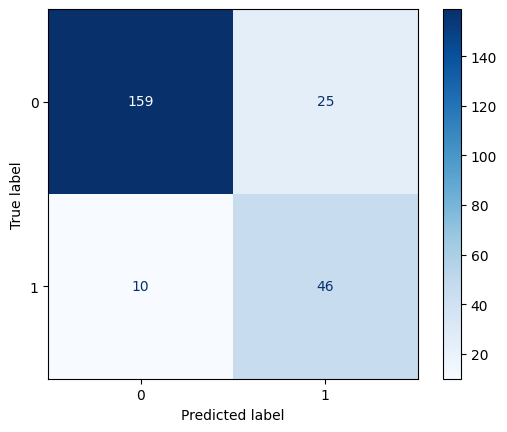

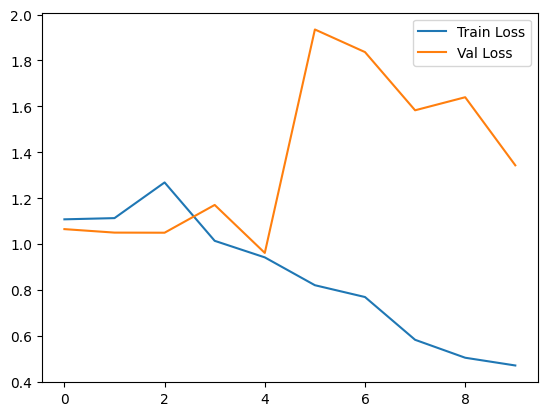

In [ ]:
# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load the best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Metrics
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
mcc = matthews_corrcoef(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"MCC: {mcc}")
print(f"ROC-AUC: {roc_auc}")
print(f"Confusion Matrix:\n{cm}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

# Plot losses
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.show()


In [ ]:
wrong_predictions = []

# Ensure test_df is aligned with all_labels and all_preds.
# test_df was created by train_test_split, so its index might not be contiguous.
# Resetting index of test_df and then iterating through it along with predictions.
# Note: all_labels and all_preds are already in the correct order corresponding to test_dataset/test_dataloader.

# Re-create a list of original test data items for easier access,
# ensuring alignment with all_labels and all_preds
# Assuming test_dataset was created from test_df

for i in range(len(all_labels)):
    true_label = all_labels[i]
    predicted_label = all_preds[i]

    if true_label != predicted_label:
        # Access the original tweet_text and Party from the test_df at the corresponding index
        # test_df contains the original data rows in the order they were processed by the DataLoader
        # So, we can directly use the original index after mapping.

        # Get the original row from test_df
        original_row = test_df.iloc[i]

        wrong_predictions.append({
            'tweet_text': original_row['tweet_text'],
            'Party': original_row['Party'],
            'true_label': int(true_label),
            'predicted_label': int(predicted_label)
        })

wrong_predictions_df = pd.DataFrame(wrong_predictions)

print("Wrong Predictions:")
print(wrong_predictions_df.head())
print(f"Total wrong predictions: {len(wrong_predictions_df)}")

# Store to CSV
wrong_predictions_df.to_csv('wrong_predictions.csv', index=False)
print("Wrong predictions saved to wrong_predictions.csv")

Wrong Predictions:
                                          tweet_text Party  true_label  \
0  humility answer building great nation ! thiru ...   BJP           0   
1             hindu support dmk . repost agree ! ! !   BJP           0   
2  நான்கரை ஆண்டுகள் அஇஅதிமுக திட்டங்களுக்கு ஸ்டிக...   TVK           0   
3  ஏழை எளிய மாணவர்களுக்கும் அறிவுப்பூர்வமான கல்வி...   BJP           0   
4  இவருடைய எந்த போட்டோவையும் பார்த்தாலும் , ஒரு வ...   DMK           0   

   predicted_label  
0                1  
1                1  
2                1  
3                1  
4                1  
Total wrong predictions: 35
Wrong predictions saved to wrong_predictions.csv


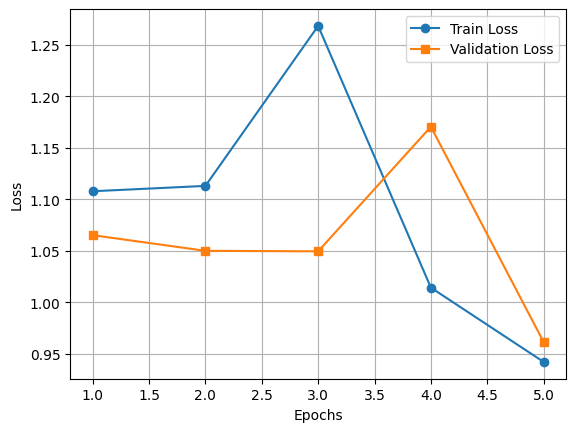

In [ ]:
import matplotlib.pyplot as plt

# Data from training log
epochs = [1, 2, 3, 4, 5]
train_loss = [1.1078, 1.1130, 1.2685, 1.0141, 0.9419]
val_loss = [1.0651, 1.0499, 1.0494, 1.1705, 0.9613]

# Plotting
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='s', label='Validation Loss')

# Labels and title
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.title('Train vs Validation Loss over Epochs')

# Legend and grid
plt.legend()
plt.grid(True)

# Show plot
plt.show()
